In [335]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.cluster import KMeans

iris_dataset=pd.read_csv("student_clustering.csv")
iris_dataset.info()
iris_dataset.dropna()

x = iris_dataset.iloc[:,0:2]
x

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   cgpa    200 non-null    float64
 1   iq      200 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.2 KB


,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110
...,...,...
195,4.68,89
196,8.57,118
197,5.85,112
198,6.23,108


Text(0, 0.5, 'WCSS')

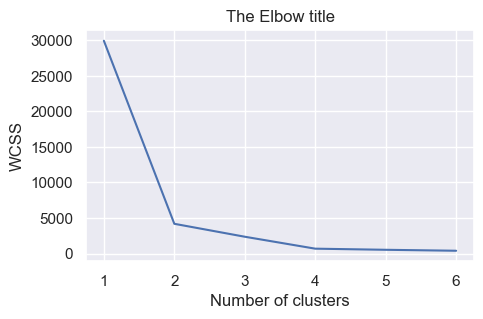

In [336]:
wcss=[]
for i in range(1,7):
 kmeans = KMeans(i)
 kmeans.fit(x)
 wcss_iter = kmeans.inertia_
 wcss.append(wcss_iter)

number_clusters = range(1,7)
plt.plot(number_clusters,wcss)
plt.title('The Elbow title')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

In [337]:
kmeans = KMeans(4)
kmeans.fit(x)

KMeans(n_clusters=4)

In [338]:
identified_clusters = kmeans.fit_predict(x)
identified_clusters

array([1, 2, 3, 3, 2, 2, 3, 0, 2, 3, 1, 2, 3, 1, 2, 3, 2, 3, 2, 2, 3, 1,
       3, 1, 1, 3, 1, 0, 3, 2, 0, 2, 0, 2, 3, 3, 0, 2, 1, 2, 1, 3, 3, 1,
       0, 0, 3, 2, 0, 2, 1, 1, 0, 3, 0, 2, 2, 0, 2, 0, 2, 3, 3, 0, 1, 0,
       3, 1, 2, 3, 2, 0, 3, 1, 2, 0, 2, 0, 1, 3, 3, 0, 2, 1, 0, 1, 0, 2,
       0, 2, 0, 0, 3, 1, 3, 3, 0, 3, 1, 0, 2, 1, 1, 0, 1, 1, 3, 1, 0, 0,
       3, 0, 2, 2, 3, 0, 3, 2, 0, 1, 1, 2, 3, 0, 3, 1, 3, 2, 1, 3, 3, 2,
       1, 1, 2, 0, 2, 1, 3, 3, 3, 1, 2, 1, 1, 0, 1, 0, 2, 1, 0, 1, 0, 0,
       1, 3, 2, 0, 2, 3, 1, 0, 2, 3, 0, 1, 2, 1, 1, 0, 0, 2, 0, 1, 1, 3,
       0, 2, 1, 0, 0, 2, 2, 2, 3, 1, 3, 3, 0, 2, 3, 3, 1, 1, 3, 1, 0, 2,
       2, 0])

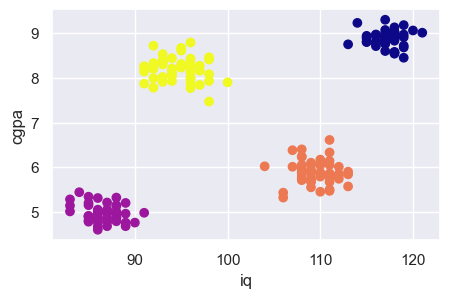

In [339]:
data_with_clusters = iris_dataset.copy()
data_with_clusters['Clusters'] = identified_clusters 
plt.scatter(data_with_clusters['iq'],data_with_clusters['cgpa'],c=data_with_clusters['Clusters'],cmap='plasma')
plt.xlabel("iq") 
plt.ylabel("cgpa")
plt.show() 

In [340]:
iris_dataset = pd.read_csv("student_clustering.csv")
iris_dataset.head()

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


In [341]:
print("Dataset shape:", iris_dataset.shape)

Dataset shape: (200, 2)


In [342]:
iris_dataset.isnull().any().any()

False

In [343]:
x = iris_dataset.loc[:, ['iq','cgpa']].values
print(x.shape)

(200, 2)


In [344]:
from sklearn.neighbors import NearestNeighbors 
neighb = NearestNeighbors(n_neighbors=2) 
nbrs=neighb.fit(x)
distances,indices=nbrs.kneighbors(x) 

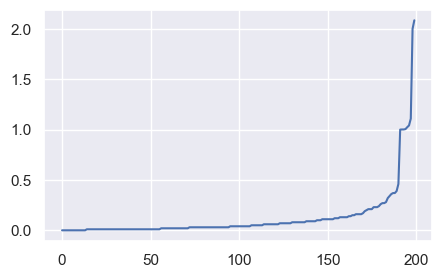

In [345]:
distances = np.sort(distances, axis = 0) 
distances = distances[:, 1] 
plt.rcParams['figure.figsize'] = (5,3) 
plt.plot(distances) 
plt.show() 

In [346]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps = 1, min_samples = 4).fit(x)
labels = dbscan.labels_

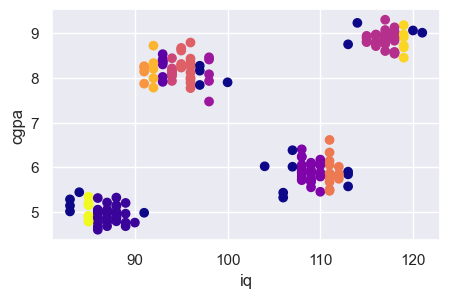

In [347]:
plt.scatter(x[:, 0], x[:,1], c = labels, cmap= "plasma") 
plt.xlabel("iq") 
plt.ylabel("cgpa") 
plt.show() 